# Notebook Outline

- Data preparation
- Graph construction
- Centrality metrics: Degree, Eigenvector, PageRank, Betweenness
- Metric comparison and correlation analysis
- Community detection: Modularity and Leiden
- Visualizations after Leiden
- Insights

# Libraries

Core libraries used for loading the data, building the graph, computing centrality, and detecting communities.

In [4]:
import warnings

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import seaborn as sns
from IPython.display import display

import igraph as ig
import leidenalg as la

warnings.filterwarnings("ignore")

In [5]:
# Load data
df_target = pd.read_csv("../../data/github_social_network/musae_git_target.csv")
df_edges = pd.read_csv("../../data/github_social_network/musae_git_edges.csv")
df_target.columns = df_target.columns.str.strip().str.lower().str.replace(" ", "_")
df_edges.columns = df_edges.columns.str.strip().str.lower().str.replace(" ", "_")

print(f"Targets: {df_target.shape[0]:,} rows")
print(f"Edges: {df_edges.shape[0]:,} rows")

# Build graph
G = nx.from_pandas_edgelist(df_edges, source="id_1", target="id_2", create_using=nx.DiGraph())
G_undirected = G.to_undirected()

print(f"Graph nodes: {G.number_of_nodes():,}")
print(f"Graph edges: {G.number_of_edges():,}")

Targets: 37,700 rows
Edges: 289,003 rows
Graph nodes: 37,700
Graph edges: 289,003


# Degree Centrality


In [6]:
# Degree Centrality
degree_centrality = nx.degree_centrality(G)
in_degree_centrality = nx.in_degree_centrality(G)
out_degree_centrality = nx.out_degree_centrality(G)

degree_centrality_df = pd.DataFrame({
    "node_id": list(G.nodes()),
    "degree_centrality": [degree_centrality.get(node, 0.0) for node in G.nodes()],
    "in_degree_centrality": [in_degree_centrality.get(node, 0.0) for node in G.nodes()],
    "out_degree_centrality": [out_degree_centrality.get(node, 0.0) for node in G.nodes()],
})

print("Top 10 by Degree Centrality")
display(degree_centrality_df.nlargest(10, "degree_centrality")[["node_id", "degree_centrality"]])

Top 10 by Degree Centrality


,node_id,degree_centrality
28,31890,0.250882
24,27803,0.187936
35,35773,0.088172
82,19222,0.078464
109,13638,0.065466
52,36652,0.062150
165,18163,0.051036
39,9051,0.047667
120,35008,0.041672
309,10001,0.041593


# Eigenvector Centrality

In [7]:
# Eigenvector Centrality
eigenvector_centrality = nx.eigenvector_centrality(G_undirected, max_iter=1000, tol=1e-06)

eigenvector_centrality_df = pd.DataFrame({
    "node_id": list(G_undirected.nodes()),
    "eigenvector_centrality": [eigenvector_centrality.get(node, 0.0) for node in G_undirected.nodes()],
})

print("Top 10 by Eigenvector Centrality")
display(eigenvector_centrality_df.nlargest(10, "eigenvector_centrality"))

Top 10 by Eigenvector Centrality


,node_id,eigenvector_centrality
28,31890,0.355949
24,27803,0.301655
35,35773,0.161677
82,19222,0.148842
109,13638,0.119461
52,36652,0.095699
117,7027,0.088758
357,36628,0.087670
39,9051,0.082797
234,3712,0.081374


# PageRank

In [8]:
# PageRank
pagerank = nx.pagerank(G, alpha=0.85)

pagerank_df = pd.DataFrame({
    "node_id": list(G.nodes()),
    "pagerank": [pagerank.get(node, 0.0) for node in G.nodes()],
})

print("Top 10 by PageRank")
display(pagerank_df.nlargest(10, "pagerank"))

Top 10 by PageRank


,node_id,pagerank
28,31890,0.019439
52,36652,0.013467
165,18163,0.010761
357,36628,0.009649
120,35008,0.005277
181,34114,0.004990
2097,2347,0.004469
1488,37471,0.004384
35,35773,0.003695
2012,37289,0.003422


# Betweenness Centrality

In [9]:
# Betweenness Centrality
sample_k = min(200, G.number_of_nodes())
betweenness_centrality = nx.betweenness_centrality(G, k=sample_k, seed=42, normalized=True)

betweenness_centrality_df = pd.DataFrame({
    "node_id": list(G.nodes()),
    "betweenness_centrality": [betweenness_centrality.get(node, 0.0) for node in G.nodes()],
})

print("Top 10 by Betweenness Centrality")
display(betweenness_centrality_df.nlargest(10, "betweenness_centrality"))

Top 10 by Betweenness Centrality


,node_id,betweenness_centrality
28,31890,0.035961
82,19222,0.017556
309,10001,0.010466
35,35773,0.010466
109,13638,0.009830
39,9051,0.008520
24,27803,0.007143
134,11051,0.006930
49,19253,0.006736
577,73,0.006266


# Compare Centralities

,node_id,degree_centrality,in_degree_centrality,out_degree_centrality,eigenvector_centrality,pagerank,betweenness_centrality
0,31890,0.250882,0.198148,0.052733,0.355949,0.019439,0.035961
1,36652,0.062150,0.060612,0.001539,0.095699,0.013467,0.000771
2,18163,0.051036,0.049285,0.001751,0.055245,0.010761,0.000693
3,36628,0.039975,0.039179,0.000796,0.087670,0.009649,0.000417
4,35008,0.041672,0.039046,0.002626,0.081334,0.005277,0.001064
5,34114,0.010690,0.010584,0.000106,0.014896,0.004990,0.000060
6,2347,0.006154,0.006154,0.000000,0.012086,0.004469,0.000000
7,37471,0.011433,0.011274,0.000159,0.036863,0.004384,0.000066
8,35773,0.088172,0.063689,0.024483,0.161677,0.003695,0.010466
9,37289,0.012679,0.012494,0.000186,0.016556,0.003422,0.000081


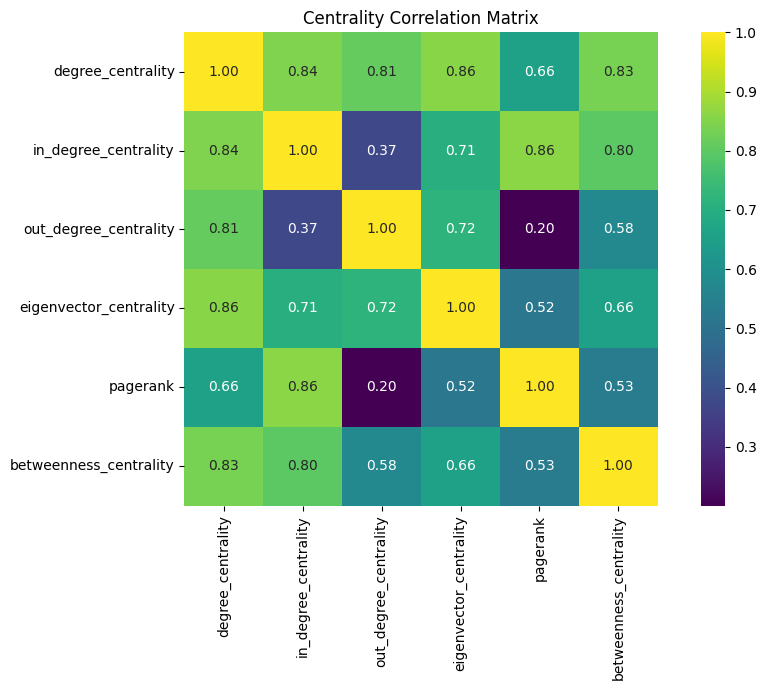

In [10]:
# Compare Centralities
centrality_df = pd.DataFrame({
    "node_id": list(G.nodes()),
    "degree_centrality": [degree_centrality.get(node, 0.0) for node in G.nodes()],
    "in_degree_centrality": [in_degree_centrality.get(node, 0.0) for node in G.nodes()],
    "out_degree_centrality": [out_degree_centrality.get(node, 0.0) for node in G.nodes()],
    "eigenvector_centrality": [eigenvector_centrality.get(node, 0.0) for node in G.nodes()],
    "pagerank": [pagerank.get(node, 0.0) for node in G.nodes()],
    "betweenness_centrality": [betweenness_centrality.get(node, 0.0) for node in G.nodes()],
})

centrality_df = centrality_df.sort_values("pagerank", ascending=False).reset_index(drop=True)

display(centrality_df.head(10))

# Correlation Analysis
correlation_columns = [
    "degree_centrality",
    "in_degree_centrality",
    "out_degree_centrality",
    "eigenvector_centrality",
    "pagerank",
    "betweenness_centrality",
]
correlation_matrix = centrality_df[correlation_columns].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, cmap="viridis", fmt=".2f", square=True)
plt.title("Centrality Correlation Matrix")
plt.tight_layout()
plt.show()

# Modularity-based Community Detection

In [11]:
# Modularity-based Community Detection
from networkx.algorithms.community import louvain_communities, modularity

louvain_communities_result = louvain_communities(G_undirected, seed=42, resolution=1.0)
louvain_modularity = modularity(G_undirected, louvain_communities_result)

print(f"Louvain communities: {len(louvain_communities_result):,}")
print(f"Louvain modularity: {louvain_modularity:.6f}")

Louvain communities: 33
Louvain modularity: 0.458239


# Leiden Algorithm

In [12]:
# Leiden Algorithm
edge_tuples = list(G_undirected.edges())
ig_graph = ig.Graph.TupleList(edge_tuples, directed=False)
leiden_partition = la.find_partition(ig_graph, la.ModularityVertexPartition, seed=42)
leiden_modularity = leiden_partition.modularity

leiden_df = pd.DataFrame({
    "node_id": ig_graph.vs["name"],
    "leiden_community": leiden_partition.membership,
})

print(f"Leiden communities: {leiden_df['leiden_community'].nunique():,}")
print(f"Leiden modularity: {leiden_modularity:.6f}")

leiden_community_sizes = (
    leiden_df["leiden_community"]
    .value_counts()
    .sort_index()
    .rename_axis("leiden_community")
    .reset_index(name="size")
)

display(leiden_community_sizes.head(10))

Leiden communities: 39
Leiden modularity: 0.452041


,leiden_community,size
0,0,8395
1,1,7852
2,2,6537
3,3,6109
4,4,2637
5,5,2250
6,6,1156
7,7,687
8,8,573
9,9,570


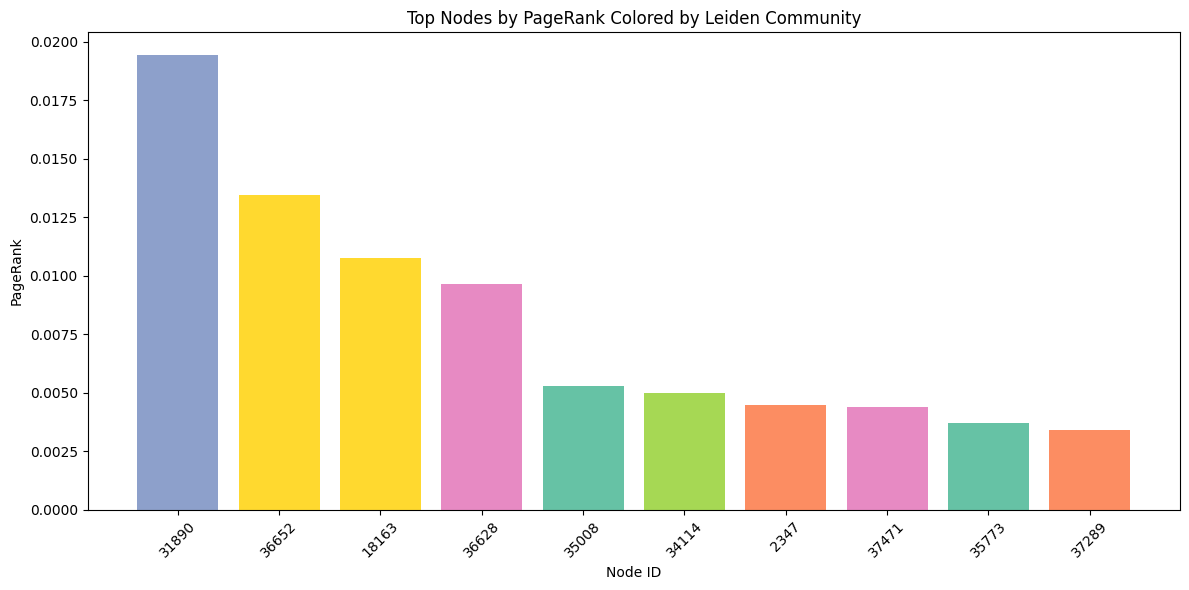

,node_id,pagerank,degree_centrality,leiden_community
0,31890,0.019439,0.250882,2
1,36652,0.013467,0.062150,5
2,18163,0.010761,0.051036,5
3,36628,0.009649,0.039975,3
4,35008,0.005277,0.041672,0
5,34114,0.004990,0.010690,4
6,2347,0.004469,0.006154,1
7,37471,0.004384,0.011433,3
8,35773,0.003695,0.088172,0
9,37289,0.003422,0.012679,1


In [13]:
# Top Node Visualization After Leiden
leiden_centrality_df = centrality_df.merge(leiden_df, on="node_id", how="left")

top_nodes_df = leiden_centrality_df.nlargest(10, "pagerank")

plt.figure(figsize=(12, 6))
colors = sns.color_palette("Set2", n_colors=top_nodes_df["leiden_community"].nunique())
community_color_map = {community: colors[idx] for idx, community in enumerate(sorted(top_nodes_df["leiden_community"].unique()))}
bar_colors = [community_color_map[community] for community in top_nodes_df["leiden_community"]]

plt.bar(top_nodes_df["node_id"].astype(str), top_nodes_df["pagerank"], color=bar_colors)
plt.title("Top Nodes by PageRank Colored by Leiden Community")
plt.xlabel("Node ID")
plt.ylabel("PageRank")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(top_nodes_df[["node_id", "pagerank", "degree_centrality", "leiden_community"]])

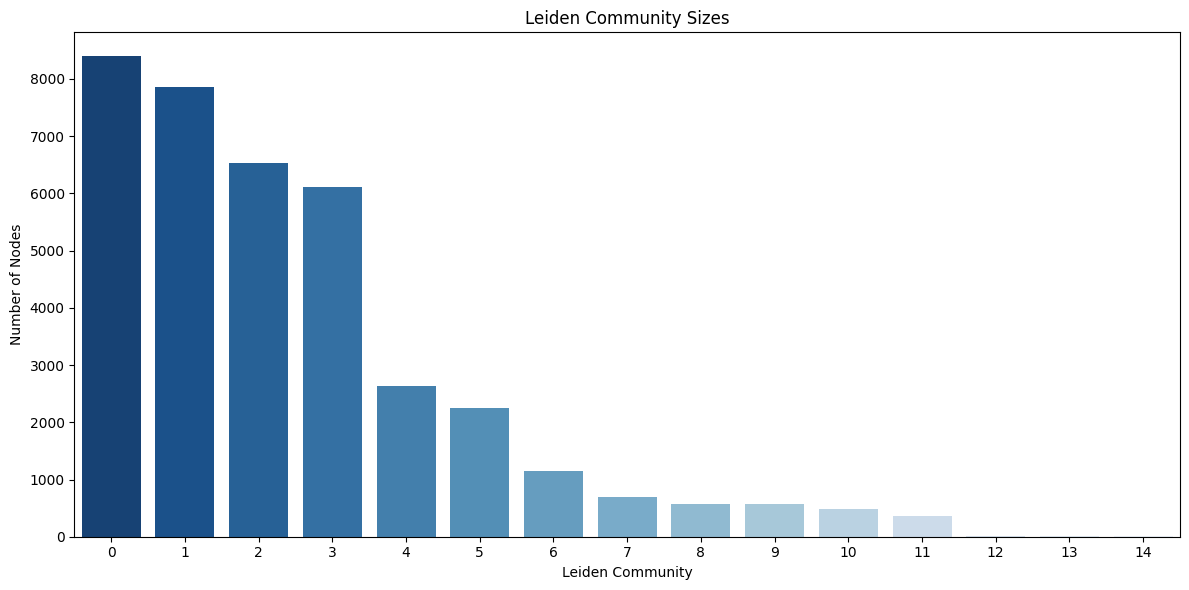

,leiden_community,size
0,0,8395
1,1,7852
2,2,6537
3,3,6109
4,4,2637
5,5,2250
6,6,1156
7,7,687
8,8,573
9,9,570


In [14]:
# Community Visualization After Leiden
plt.figure(figsize=(12, 6))
community_plot_df = leiden_community_sizes.sort_values("size", ascending=False)

sns.barplot(data=community_plot_df.head(15), x="leiden_community", y="size", palette="Blues_r")
plt.title("Leiden Community Sizes")
plt.xlabel("Leiden Community")
plt.ylabel("Number of Nodes")
plt.tight_layout()
plt.show()

display(community_plot_df.head(15))